### Utilizar y cargar las librerías necesarías para el EDA

In [1]:
import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import os
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
from extraccion import Extraccion

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14

print('Librerías cargadas correctamente.')

Matplotlib is building the font cache; this may take a moment.


Librerías cargadas correctamente.


#### Iniciar la conexión a MongoDB y extrar los datos

In [2]:
ext = Extraccion(uri='mongodb://localhost:27017', db_name='airbnb_mexico')
ext.conectar()
dfs = ext.extraer_todo()
ext.cerrar_conexion()

df_listings  = dfs['listings']
df_calendar  = dfs['calendar']
df_reviews   = dfs['reviews']

print(f'Listings:  {df_listings.shape[0]:,} filas × {df_listings.shape[1]} columnas')
print(f'Calendar:  {df_calendar.shape[0]:,} filas × {df_calendar.shape[1]} columnas')
print(f'Reviews:   {df_reviews.shape[0]:,} filas × {df_reviews.shape[1]} columnas')

2026-04-11 14:39:18 | INFO     | extraccion | Logger 'extraccion' iniciado — archivo: C:\Users\josem\Documents\ITM\Semestre10\Inteligencia Negocios\Taller2\etl_airbnb\logs\log_20260411_1439.txt
2026-04-11 14:39:18 | INFO     | extraccion | Extraccion inicializada — URI: mongodb://localhost:27017 | DB: airbnb_mexico
2026-04-11 14:39:18 | INFO     | extraccion | Intentando conectar a MongoDB...
2026-04-11 14:39:18 | INFO     | extraccion | Conexión exitosa a MongoDB — Base de datos: 'airbnb_mexico'
2026-04-11 14:39:19 | INFO     | extraccion | Colecciones disponibles: ['listings', 'calendar', 'reviews']
2026-04-11 14:39:19 | INFO     | extraccion | === Iniciando extracción completa de colecciones ===
2026-04-11 14:39:19 | INFO     | extraccion | Extrayendo colección: 'listings'...
2026-04-11 14:39:23 | INFO     | extraccion |   ✓ 'listings': 27,051 registros | 76 columnas
2026-04-11 14:39:23 | INFO     | extraccion | Extrayendo colección: 'reviews'...
2026-04-11 14:39:47 | INFO     | ext

Listings:  27,051 filas × 76 columnas
Calendar:  9,873,624 filas × 5 columnas
Reviews:   1,454,740 filas × 6 columnas


# Punto 2: Analisis exploratorio de datos (EDA)

## Item 2.1. Entendimiento general de los datos

### Para cada colección:

#### Mostrar las primeras filas

Para la colección de Listings

In [3]:
print('=== Primeras filas de Listings ===')
df_listings.head(5)

=== Primeras 5 filas de Listings ===


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,...,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,host_neighbourhood,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,35797,https://www.airbnb.com/rooms/35797,20250927041820,2025-09-27,city scrape,Villa Dante,"Dentro de Villa un estudio de arte con futon, ...","Santa Fe Shopping Mall, Interlomas Park and th...",https://a0.muscache.com/pictures/f395ab78-1185...,153786,https://www.airbnb.com/users/show/153786,Dici,2010-06-28,"Mexico City, Mexico","Master in visual arts, film photography & Mark...",N/A,N/A,N/A,False,https://a0.muscache.com/im/pictures/user/00de1...,https://a0.muscache.com/im/pictures/user/00de1...,1.00,1.00,"['email', 'phone', 'work_email']",True,...,363,2025-09-27,0,0,0,94,0,0,0.00,False,1,1,0,0,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,44616,https://www.airbnb.com/rooms/44616,20250927041820,2025-09-28,city scrape,Condesa Haus,A new concept of hosting in mexico through a b...,NaN,https://a0.muscache.com/pictures/251410/ec75fe...,196253,https://www.airbnb.com/users/show/196253,Fernando,2010-08-09,"Mexico City, Mexico",Condesa Haus Rentals offers independent stud...,within an hour,100%,92%,False,https://a0.muscache.com/im/users/196253/profil...,https://a0.muscache.com/im/users/196253/profil...,13.00,13.00,"['email', 'phone', 'work_email']",True,...,360,2025-09-28,65,1,0,90,0,6,108000.00,False,9,4,2,0,Condesa,2011-11-09,2025-01-01,4.59,4.56,4.70,4.87,4.78,4.98,4.47,0.38
2,56074,https://www.airbnb.com/rooms/56074,20250927041820,2025-09-28,city scrape,Great space in historical San Rafael,This great apartment is located in one of the ...,Very traditional neighborhood with all service...,https://a0.muscache.com/pictures/3005118/60dac...,265650,https://www.airbnb.com/users/show/265650,Maris,2010-10-19,"Mexico City, Mexico",I am a University Professor now retired after ...,within a day,100%,100%,True,https://a0.muscache.com/im/users/265650/profil...,https://a0.muscache.com/im/users/265650/profil...,1.00,5.00,"['email', 'phone']",True,...,333,2025-09-28,84,1,0,63,0,30,17730.00,False,1,1,0,0,San Rafael,2011-04-02,2025-02-27,4.87,4.95,4.88,4.98,4.94,4.76,4.79,0.48
3,67703,https://www.airbnb.com/rooms/67703,20250927041820,2025-09-28,previous scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",NaN,https://a0.muscache.com/pictures/3281720/6f078...,334451,https://www.airbnb.com/users/show/334451,Nicholas,2011-01-04,"Mexico City, Mexico","I am a journalist writing about food, (book an...",within a few hours,88%,43%,False,https://a0.muscache.com/im/users/334451/profil...,https://a0.muscache.com/im/users/334451/profil...,3.00,4.00,"['email', 'phone']",True,...,252,2025-09-28,50,1,0,9,4,6,NaN,False,2,2,0,0,Hipódromo,2011-11-17,2024-10-30,4.90,4.82,4.76,4.94,4.92,4.98,4.92,0.30
4,70644,https://www.airbnb.com/rooms/70644,20250927041820,2025-09-28,previous scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,https://a0.muscache.com/pictures/f397d2da-d045...,212109,https://www.airbnb.com/users/show/212109,Trisha,2010-08-24,"Mexico City, Mexico","I am a documenta

In [ ]:
# listar solo los datos del campo de precio
print(df_listings["price"].head(10))

0     $3,673.00
1    $18,000.00
2       $591.00
3           NaN
4           NaN
5           NaN
6     $3,673.00
7       $321.00
8     $1,190.00
9           NaN
Name: price, dtype: str


In [4]:
print(f'Shape: {df_listings.shape}')
df_listings.info()

Shape: (27051, 76)
<class 'pandas.DataFrame'>
RangeIndex: 27051 entries, 0 to 27050
Data columns (total 76 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            27051 non-null  int64         
 1   listing_url                                   27051 non-null  str           
 2   scrape_id                                     27051 non-null  int64         
 3   last_scraped                                  27051 non-null  datetime64[us]
 4   source                                        27051 non-null  str           
 5   name                                          27051 non-null  object        
 6   description                                   26309 non-null  str           
 7   neighborhood_overview                         13736 non-null  str           
 8   picture_url                                   27051 non-nu

In [35]:
def transformar_listings(self, df: pd.DataFrame) -> pd.DataFrame:
    self.logger.info("=== Transformando Listings ===")
    self.logger.info(f"  Columnas disponibles: {list(df.columns)}")  # <-- agregar esta línea
    self.logger.info(f"  'price' en columnas: {'price' in df.columns}")  # <-- y esta
    antes = len(df)
    df = df.copy()

#### Descripción estadística de variables numéricas relevantes

In [36]:
cols_num = ['price', 'minimum_nights', 'maximum_nights', 'availability_365',
            'number_of_reviews', 'review_scores_rating', 'reviews_per_month']
cols_existentes = [c for c in cols_num if c in df_listings.columns]
df_listings[cols_existentes].describe().round(2)

,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,reviews_per_month
count,27051.00,27051.00,27051.00,27051.00,23650.00,23650.00
mean,4.58,480.08,232.69,53.78,4.75,1.85
std,24.78,396.36,122.27,85.14,0.38,2.28
min,1.00,1.00,0.00,0.00,1.00,0.01
25%,1.00,180.00,140.00,4.00,4.70,0.45
50%,2.00,365.00,269.00,21.00,4.84,1.26
75%,2.00,730.00,341.00,69.00,4.95,2.62
max,1125.00,1127.00,365.00,1434.00,5.00,119.46


Para la colección de Calendar

In [6]:
df_calendar.head(5)

,listing_id,date,available,minimum_nights,maximum_nights
0,7860479,2025-09-28,False,5,28
1,7860479,2025-09-29,False,5,28
2,7860479,2025-09-30,False,5,28
3,7860479,2025-10-01,False,5,28
4,7860479,2025-10-02,False,5,28


In [37]:
print(f'Shape: {df_calendar.shape}')
df_calendar.info()

Shape: (9873624, 5)
<class 'pandas.DataFrame'>
RangeIndex: 9873624 entries, 0 to 9873623
Data columns (total 5 columns):
 #   Column          Dtype         
---  ------          -----         
 0   listing_id      int64         
 1   date            datetime64[us]
 2   available       bool          
 3   minimum_nights  int64         
 4   maximum_nights  int64         
dtypes: bool(1), datetime64[us](1), int64(3)
memory usage: 310.7 MB


Para la colección de Reviews

In [8]:
df_reviews.head(5)

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,7860479,1025476588036300970,2023-11-15,278976129,Rigoberto,"My stay was perfect! This home is beautiful, c..."
1,7860479,1276994177504599518,2024-10-27,52727016,Maria De La Paz,Hospedarse con Luz es un lujo. Su espacio es m...
2,7860479,1286338557680968180,2024-11-09,512297504,Jennyfer,Hospedarme con Luz ha sido la mejor decisión. ...
3,7868766,47594952,2015-09-20,44224399,Justin,Enrique was a great host! I was in town on sho...
4,7868766,48646103,2015-09-27,42732178,Jessica,This apartment has a good location and it is v...


In [9]:
print(f'Shape: {df_reviews.shape}')
df_reviews.info()

Shape: (1454740, 6)
<class 'pandas.DataFrame'>
RangeIndex: 1454740 entries, 0 to 1454739
Data columns (total 6 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   listing_id     1454740 non-null  int64         
 1   id             1454740 non-null  int64         
 2   date           1454740 non-null  datetime64[us]
 3   reviewer_id    1454740 non-null  int64         
 4   reviewer_name  1454727 non-null  object        
 5   comments       1454740 non-null  object        
dtypes: datetime64[us](1), int64(3), object(2)
memory usage: 66.6+ MB


## 2.2. Calidad de los datos

#### Identificación de valores nulos

In [11]:
def resumen_nulos(df, nombre):
    """Genera un resumen de nulos ordenado por porcentaje."""
    nulos = df.isnull().sum()
    porcentaje = (nulos / len(df) * 100).round(2)
    resumen = pd.DataFrame({'nulos': nulos, 'porcentaje': porcentaje})
    resumen = resumen[resumen['nulos'] > 0].sort_values('porcentaje', ascending=False)
    print(f'\n=== Nulos en {nombre} ({len(resumen)} columnas con nulos) ===')
    display(resumen.head(20))
    return resumen

nulos_listings = resumen_nulos(df_listings, 'Listings')
nulos_calendar = resumen_nulos(df_calendar, 'Calendar')
nulos_reviews  = resumen_nulos(df_reviews, 'Reviews')


=== Nulos en Listings (39 columnas con nulos) ===


,nulos,porcentaje
neighborhood_overview,13315,49.22
neighbourhood,13315,49.22
host_neighbourhood,12264,45.34
host_about,10829,40.03
host_location,5827,21.54
beds,3506,12.96
bathrooms,3496,12.92
estimated_revenue_l365d,3484,12.88
price,3484,12.88
review_scores_checkin,3402,12.58



=== Nulos en Calendar (0 columnas con nulos) ===


,nulos,porcentaje



=== Nulos en Reviews (1 columnas con nulos) ===


,nulos,porcentaje
reviewer_name,13,0.00


In [12]:
print('=== Filas con null ===')
df_listings[df_listings['has_availability'].isnull()].head(13)

=== Filas con null ===


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,...,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,host_neighbourhood,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
5,131610,https://www.airbnb.com/rooms/131610,20250927041820,2025-09-28,previous scrape,MARIA DEL ALMA,NaN,NaN,https://a0.muscache.com/pictures/837085/b9ed71...,647454,https://www.airbnb.com/users/show/647454,Fernando,2011-05-31,"Mexico City, Mexico",NaN,N/A,N/A,N/A,False,https://a0.muscache.com/im/pictures/user/0e667...,https://a0.muscache.com/im/pictures/user/0e667...,3.00,4.00,['phone'],True,...,0,2025-09-28,0,0,0,0,0,0,NaN,False,3,1,2,0,Coyoacán,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,276504,https://www.airbnb.com/rooms/276504,20250927041820,2025-09-28,previous scrape,High End Condo with golf package,NaN,NaN,https://a0.muscache.com/pictures/2802432/4be14...,1444589,https://www.airbnb.com/users/show/1444589,Michael,2011-11-26,NaN,NaN,N/A,N/A,N/A,False,https://a0.muscache.com/im/users/1444589/profi...,https://a0.muscache.com/im/users/1444589/profi...,1.00,1.00,"['email', 'phone']",True,...,0,2025-09-28,0,0,0,0,0,0,NaN,False,1,1,0,0,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,291804,https://www.airbnb.com/rooms/291804,20250927041820,2025-09-28,previous scrape,A nice room with great location,NaN,NaN,https://a0.muscache.com/pictures/3323620/a48d3...,1511568,https://www.airbnb.com/users/show/1511568,Luis Ernesto,2011-12-16,"Mexico City, Mexico","My name is Luis, I live in mexico city and I h...",N/A,N/A,N/A,False,https://a0.muscache.com/im/users/1511568/profi...,https://a0.muscache.com/im/users/1511568/profi...,1.00,1.00,"['email', 'phone']",True,...,0,2025-09-28,0,0,0,0,0,0,NaN,False,1,0,1,0,Portales,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,325812,https://www.airbnb.com/rooms/325812,20250927041820,2025-09-28,previous scrape,"Confortable private room, downtown Mexico City.",(only women) WELCOME to an EXCELLENT LOCATION ...,NEIGHBORHOOD: Super interesting!!! Walking thr...,https://a0.muscache.com/pictures/81f2a2a5-0ac6...,1666388,https://www.airbnb.com/users/show/1666388,Angeles (Anjali),2012-01-28,"Mexico City, Mexico",ENGLISH: I love to travel and have been fortun...,N/A,N/A,N/A,False,https://a0.muscache.com/im/users/1666388/profi...,https://a0.muscache.com/im/users/1666388/profi...,1.00,2.00,"['email', 'phone']",True,...,0,2025-09-28,106,0,0,0,0,0,NaN,False,1,0,1,0,Centro Histórico,2014-02-16,2020-09-19,4.78,4.79,4.85,4.86,4.86,4.93,4.78,0.75
28,350079,https://www.airbnb.com/rooms/350079,20250927041820,2025-09-28,previous scrape,beautiful furnished room Rome area,NaN,NaN,https://a0.muscache.com/pictures/3875519/b11cd...,1773936,https://www.airbnb.com/users/show/1773936,Elizabeth,2012-02-19,"Mexico City, Mexico","IM 40 YEARS OLD LESBIAN WOMAN , WHO LOVE TO LI...",N/A,N/A,N/A,False,https://a0.muscache.com/im/users/1773936/profi...,https://a0.muscache.com/im/users/1773936/profi...,1.00,1.00,"['email', 'phone']",True,...,0,2025-09-28,0,0,0,0,0,0,NaN,False,1,0,1,0,Roma Sur,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,642725,https://www.airbnb.com/rooms/642725,20250927041820,2025-09-28,previous scrape,Recamara en depa a 5 minutos del metropolitano,"north of the city, close to main square

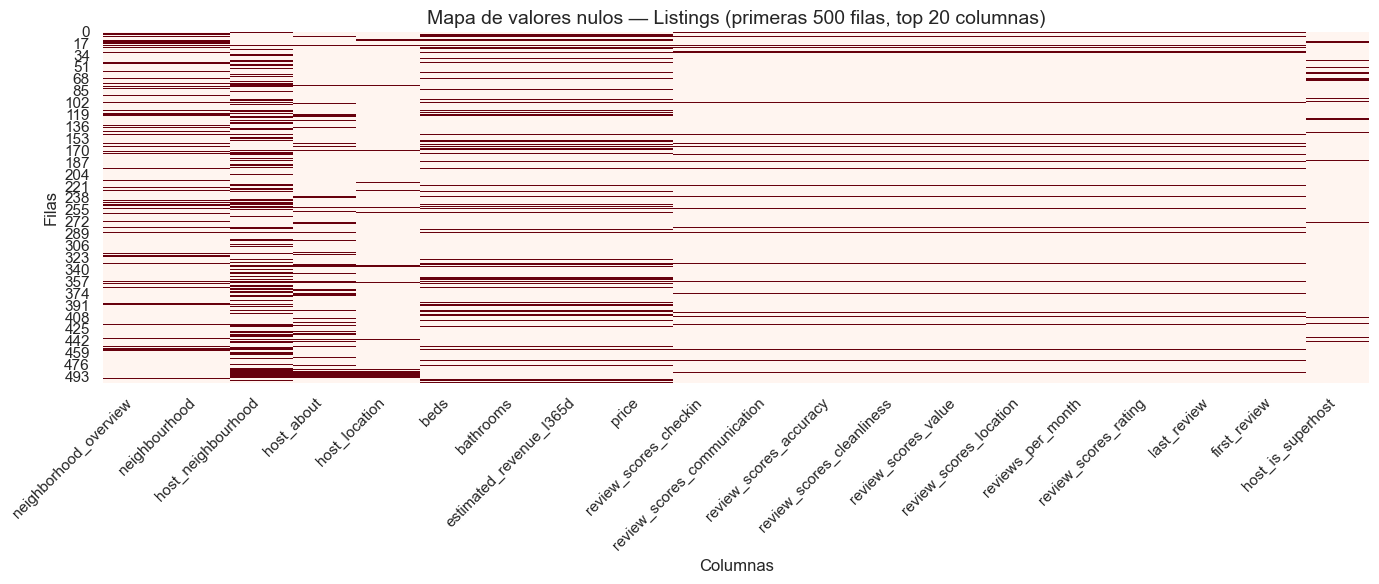

Gráfica guardada.


In [13]:
# Mapa de calor de nulos — Listings (top 20 columnas con más nulos)
top_nulos = nulos_listings.head(20).index.tolist()
if top_nulos:
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(
        df_listings[top_nulos].isnull().astype(int).head(500),
        cmap='Reds', cbar=False, ax=ax
    )
    ax.set_title('Mapa de valores nulos — Listings (primeras 500 filas, top 20 columnas)')
    ax.set_xlabel('Columnas')
    ax.set_ylabel('Filas')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../data/grafica_nulos_listings.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfica guardada.')

#### Registros duplicados

In [14]:
def df_hashable(df):
    """Convierte columnas con listas u objetos no hasheables a string para poder comparar duplicados."""
    df_temp = df.copy()
    for col in df_temp.columns:
        if df_temp[col].dtype == object:
            df_temp[col] = df_temp[col].apply(
                lambda x: str(x) if isinstance(x, (list, dict)) else x
            )
    return df_temp

for nombre, df in [('Listings', df_listings), ('Calendar', df_calendar), ('Reviews', df_reviews)]:
    df_safe = df_hashable(df)
    
    dup_total = df_safe.duplicated().sum()
    
    col_id = 'id' if 'id' in df_safe.columns else None
    if col_id:
        dup_id = df_safe[col_id].astype(str).duplicated().sum()
    else:
        dup_id = 'N/A'
    
    print(f'{nombre}: {dup_total} duplicados totales | {dup_id} duplicados por ID')

Listings: 0 duplicados totales | 0 duplicados por ID
Calendar: 0 duplicados totales | N/A duplicados por ID
Reviews: 0 duplicados totales | 0 duplicados por ID


#### Valores atípicos detectados en variables clave

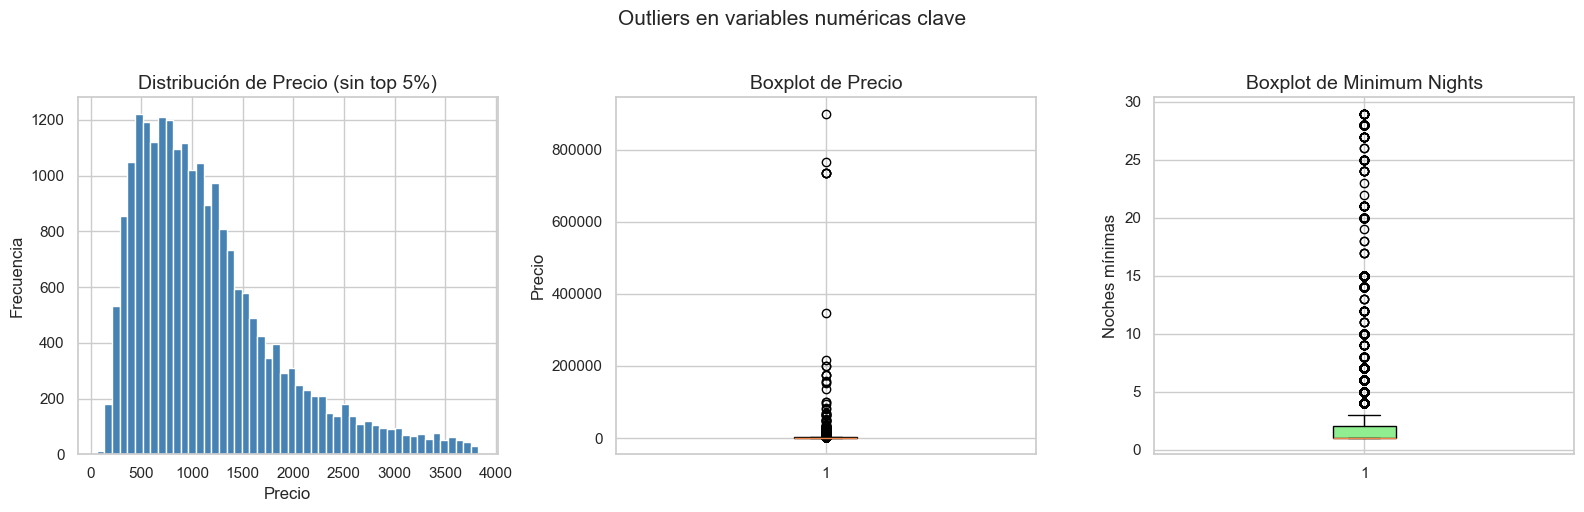


Outliers en precio (método IQR): 1,768 registros (6.5%)
Precio mediano: $1039.00
Precio máximo: $900000.00


In [16]:
# Normalizar precio para análisis (eliminar $ y comas)
if 'price' in df_listings.columns:
    precio_num = (
        df_listings['price']
        .astype(str)
        .str.replace(r'[\$,\s]', '', regex=True)
        .replace('nan', None)
    )
    precio_num = pd.to_numeric(precio_num, errors='coerce')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Histograma precio
    precio_filtrado = precio_num[precio_num < precio_num.quantile(0.95)]
    axes[0].hist(precio_filtrado.dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[0].set_title('Distribución de Precio (sin top 5%)')
    axes[0].set_xlabel('Precio')
    axes[0].set_ylabel('Frecuencia')

    # Boxplot precio
    axes[1].boxplot(precio_num.dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[1].set_title('Boxplot de Precio')
    axes[1].set_ylabel('Precio')

    # Boxplot minimum_nights
    if 'minimum_nights' in df_listings.columns:
        mn = pd.to_numeric(df_listings['minimum_nights'], errors='coerce')
        mn_filtrado = mn[mn < mn.quantile(0.99)]
        axes[2].boxplot(mn_filtrado.dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightgreen'))
        axes[2].set_title('Boxplot de Minimum Nights')
        axes[2].set_ylabel('Noches mínimas')

    plt.suptitle('Outliers en variables numéricas clave', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.savefig('../data/grafica_valores_atipicos.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Estadísticas de outliers
    Q1, Q3 = precio_num.quantile(0.25), precio_num.quantile(0.75)
    IQR = Q3 - Q1
    outliers = precio_num[(precio_num < Q1 - 1.5*IQR) | (precio_num > Q3 + 1.5*IQR)]
    print(f'\nOutliers en precio (método IQR): {len(outliers):,} registros ({len(outliers)/len(precio_num)*100:.1f}%)')
    print(f'Precio mediano: ${precio_num.median():.2f}')
    print(f'Precio máximo: ${precio_num.max():.2f}')

### Distribución de variables categóricas

#### Tipo de habitación

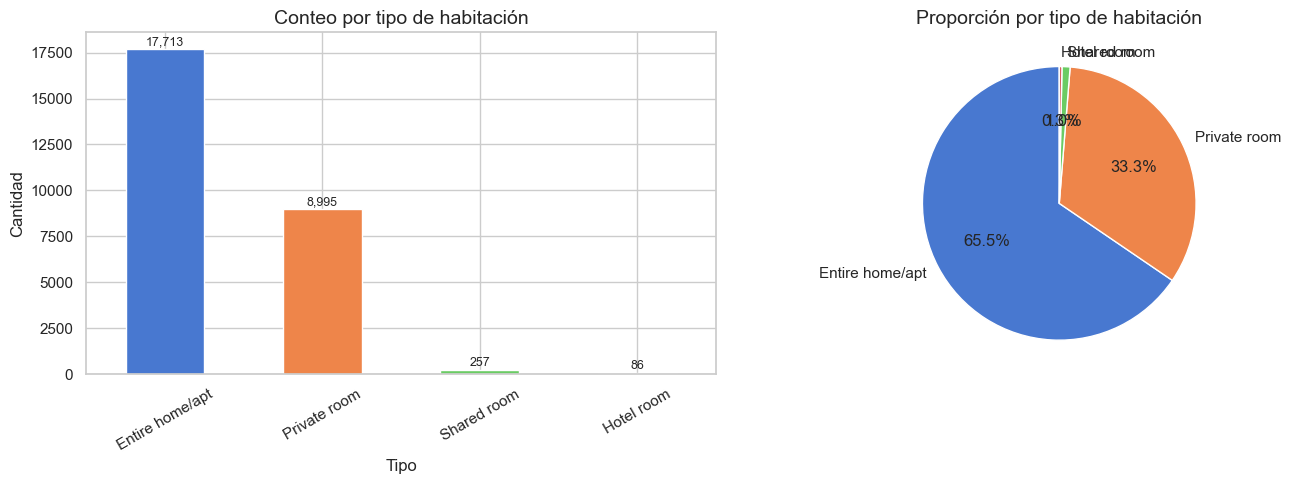

room_type
Entire home/apt    17713
Private room        8995
Shared room          257
Hotel room            86


In [17]:
import os
os.makedirs('../data', exist_ok=True)
if 'room_type' in df_listings.columns:
    conteo = df_listings['room_type'].value_counts()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Barras
    conteo.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted'), edgecolor='white')
    axes[0].set_title('Conteo por tipo de habitación')
    axes[0].set_xlabel('Tipo')
    axes[0].set_ylabel('Cantidad')
    axes[0].tick_params(axis='x', rotation=30)
    for bar in axes[0].patches:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                     f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
    
    # Torta
    axes[1].pie(conteo, labels=conteo.index, autopct='%1.1f%%',
                colors=sns.color_palette('muted'), startangle=90)
    axes[1].set_title('Proporción por tipo de habitación')
    
    plt.tight_layout()
    plt.savefig('../data/grafica_room_type.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(conteo.to_string())

#### Ver los barrios con mas listados

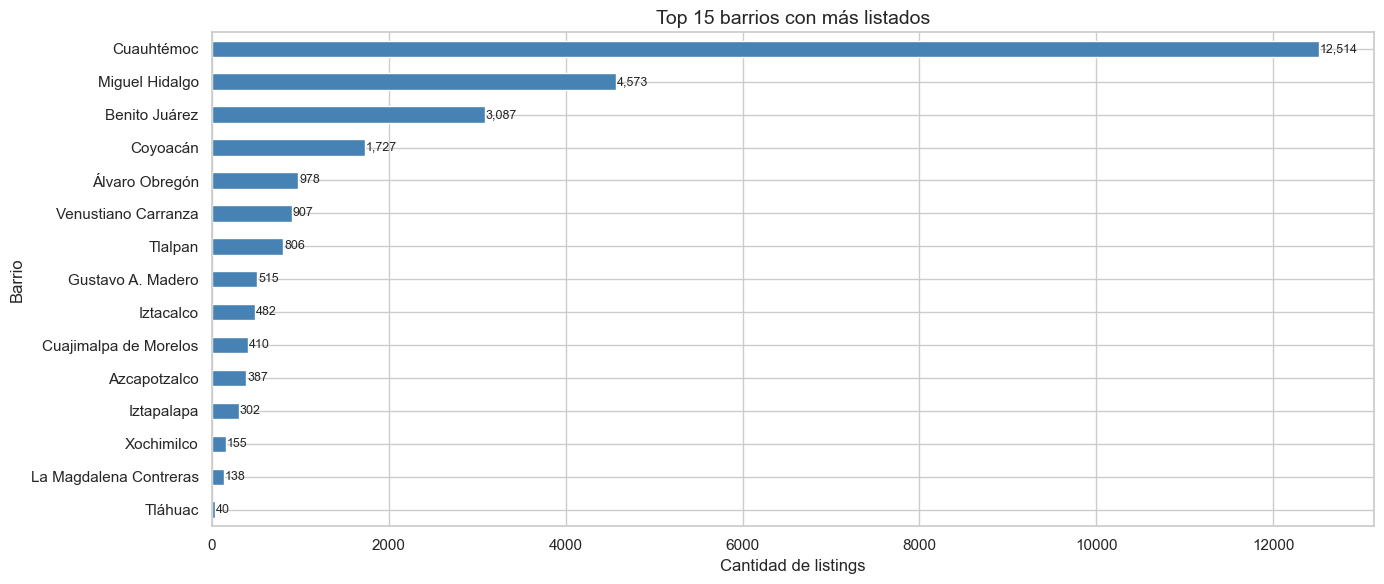

In [38]:
col_barrio = next((c for c in ['neighbourhood_cleansed', 'neighbourhood', 'neighborhood']
                   if c in df_listings.columns), None)

if col_barrio:
    top_barrios = df_listings[col_barrio].value_counts().head(15)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    top_barrios.sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Top 15 barrios con más listados')
    ax.set_xlabel('Cantidad de listings')
    ax.set_ylabel('Barrio')
    for i, v in enumerate(top_barrios.sort_values()):
        ax.text(v + 10, i, f'{v:,}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('../data/grafica_barrios.png', dpi=150, bbox_inches='tight')
    plt.show()

#### Disponibilidad promedio - Noches minimas y maximas - Ocupacion estimada

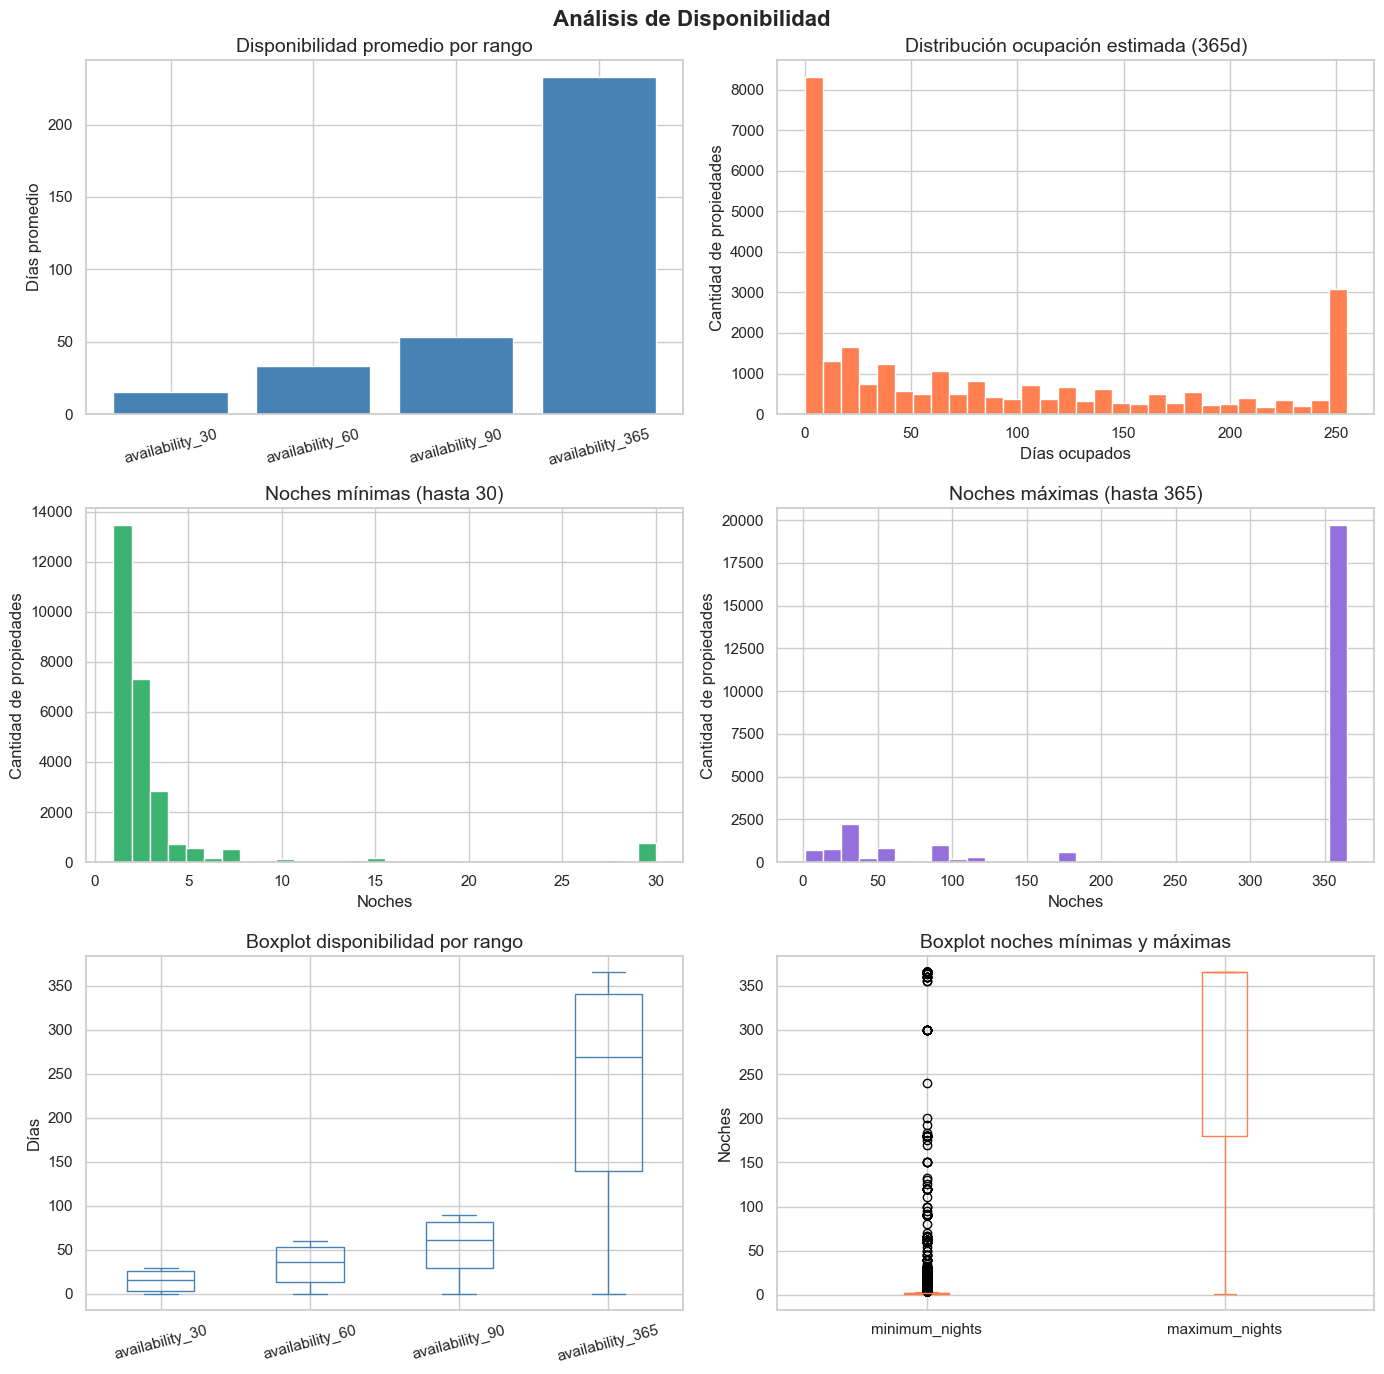

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('Análisis de Disponibilidad', fontsize=16, fontweight='bold')

# 1. Disponibilidad promedio por rango
disponibilidad_media = df_listings[['availability_30', 'availability_60', 'availability_90', 'availability_365']].mean().round(2)
axes[0, 0].bar(disponibilidad_media.index, disponibilidad_media.values, color='steelblue')
axes[0, 0].set_title('Disponibilidad promedio por rango')
axes[0, 0].set_ylabel('Días promedio')
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. Distribución ocupación estimada
axes[0, 1].hist(df_listings['estimated_occupancy_l365d'].dropna(), bins=30, color='coral', edgecolor='white')
axes[0, 1].set_title('Distribución ocupación estimada (365d)')
axes[0, 1].set_xlabel('Días ocupados')
axes[0, 1].set_ylabel('Cantidad de propiedades')

# 3. Distribución noches mínimas (sin outliers)
min_nights = df_listings['minimum_nights'].clip(upper=30)
axes[1, 0].hist(min_nights, bins=30, color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title('Noches mínimas (hasta 30)')
axes[1, 0].set_xlabel('Noches')
axes[1, 0].set_ylabel('Cantidad de propiedades')

# 4. Distribución noches máximas (sin outliers)
max_nights = df_listings['maximum_nights'].clip(upper=365)
axes[1, 1].hist(max_nights, bins=30, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('Noches máximas (hasta 365)')
axes[1, 1].set_xlabel('Noches')
axes[1, 1].set_ylabel('Cantidad de propiedades')

# 5. Boxplot disponibilidad
df_listings[['availability_30', 'availability_60', 'availability_90', 'availability_365']].plot(
    kind='box', ax=axes[2, 0], color='steelblue'
)
axes[2, 0].set_title('Boxplot disponibilidad por rango')
axes[2, 0].set_ylabel('Días')
axes[2, 0].tick_params(axis='x', rotation=15)

# 6. Boxplot noches mínimas y máximas (sin outliers)
df_listings[['minimum_nights', 'maximum_nights']].clip(upper=365).plot(
    kind='box', ax=axes[2, 1], color='coral'
)
axes[2, 1].set_title('Boxplot noches mínimas y máximas')
axes[2, 1].set_ylabel('Noches')

plt.tight_layout()
plt.savefig('../data/disponibilidad_promedio.png', dpi=150, bbox_inches='tight')
plt.show()

#### Precio mediano por tipo de habitación

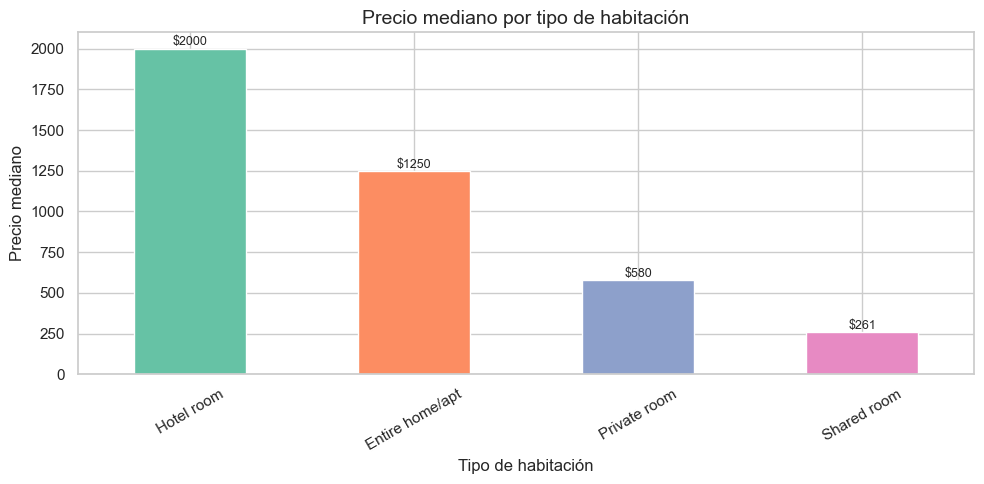

In [21]:
if 'room_type' in df_listings.columns and 'price' in df_listings.columns:
    df_temp = df_listings.copy()
    df_temp['price_num'] = pd.to_numeric(
        df_temp['price'].astype(str).str.replace(r'[\$,\s]', '', regex=True),
        errors='coerce'
    )
    precio_por_tipo = df_temp.groupby('room_type')['price_num'].median().sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    precio_por_tipo.plot(kind='bar', ax=ax, color=sns.color_palette('Set2'))
    ax.set_title('Precio mediano por tipo de habitación')
    ax.set_xlabel('Tipo de habitación')
    ax.set_ylabel('Precio mediano')
    ax.tick_params(axis='x', rotation=30)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'${bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig('../data/grafica_precio_tipo_habitacion.png', dpi=150, bbox_inches='tight')
    plt.show()

#### Disponibilidad a lo largo del año 

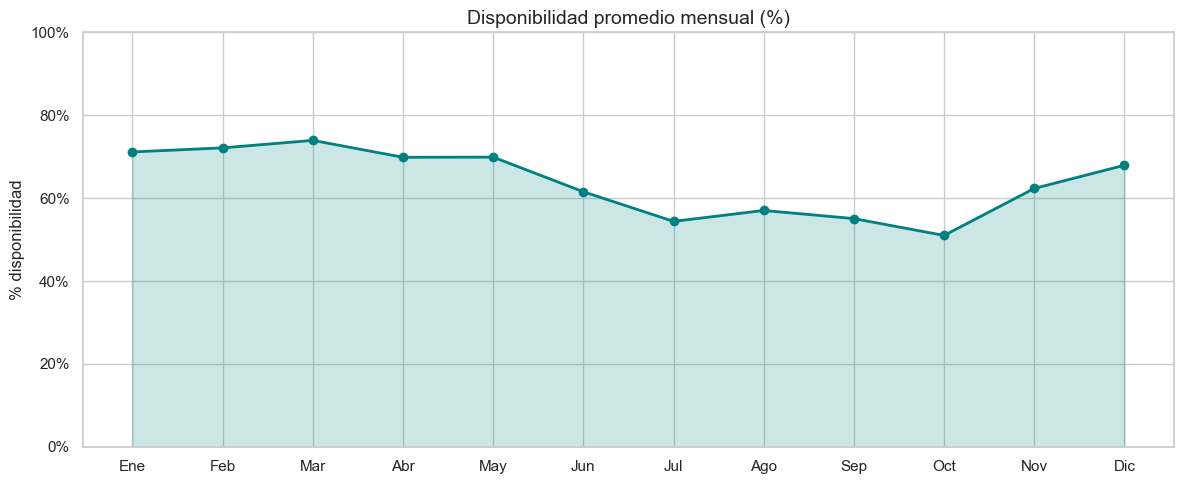

In [22]:
if 'available' in df_calendar.columns and 'date' in df_calendar.columns:
    df_cal = df_calendar.copy()
    df_cal['date'] = pd.to_datetime(df_cal['date'], errors='coerce')
    df_cal['mes'] = df_cal['date'].dt.month
    df_cal['disponible'] = df_cal['available'].map({'t': 1, 'f': 0, True: 1, False: 0})
    
    disponibilidad_mes = df_cal.groupby('mes')['disponible'].mean() * 100
    
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    disponibilidad_mes.index = [meses[i-1] for i in disponibilidad_mes.index]
    
    fig, ax = plt.subplots(figsize=(12, 5))
    disponibilidad_mes.plot(kind='line', marker='o', ax=ax, color='teal', linewidth=2)
    ax.fill_between(range(len(disponibilidad_mes)), disponibilidad_mes.values, alpha=0.2, color='teal')
    ax.set_xticks(range(len(disponibilidad_mes)))
    ax.set_xticklabels(disponibilidad_mes.index)
    ax.set_title('Disponibilidad promedio mensual (%)')
    ax.set_ylabel('% disponibilidad')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.savefig('../data/grafica_disponibilidad_mensual.png', dpi=150, bbox_inches='tight')
    plt.show()

#### Evolución de reviews por año

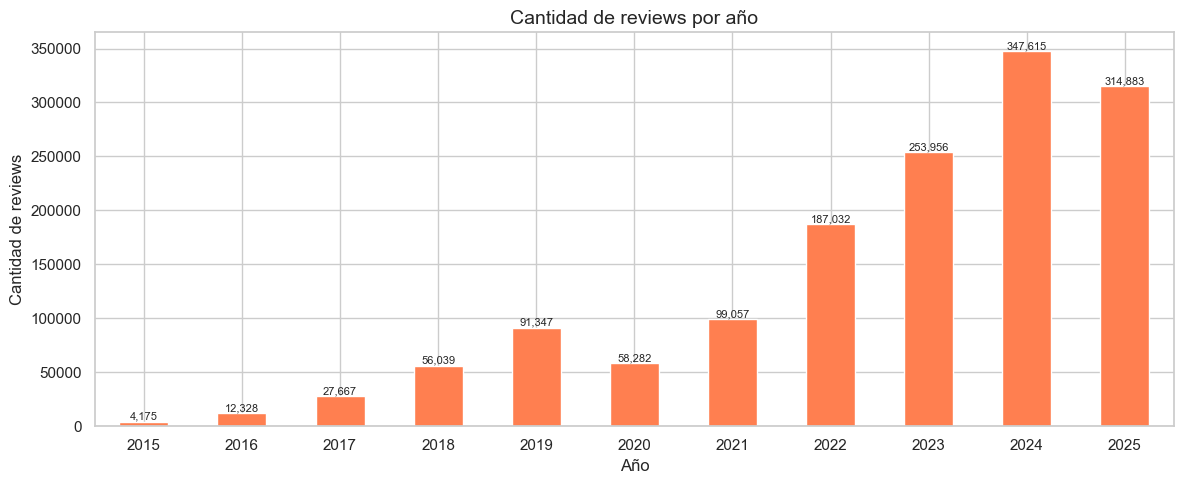

In [23]:
if 'date' in df_reviews.columns:
    df_rev = df_reviews.copy()
    df_rev['date'] = pd.to_datetime(df_rev['date'], errors='coerce')
    df_rev['anio'] = df_rev['date'].dt.year
    
    reviews_anio = df_rev['anio'].value_counts().sort_index()
    reviews_anio = reviews_anio[reviews_anio.index >= 2015]  # Filtrar años relevantes
    
    fig, ax = plt.subplots(figsize=(12, 5))
    reviews_anio.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
    ax.set_title('Cantidad de reviews por año')
    ax.set_xlabel('Año')
    ax.set_ylabel('Cantidad de reviews')
    ax.tick_params(axis='x', rotation=0)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.savefig('../data/grafica_reviews_anio.png', dpi=150, bbox_inches='tight')
    plt.show()

### Correlaciones entre variables numéricas

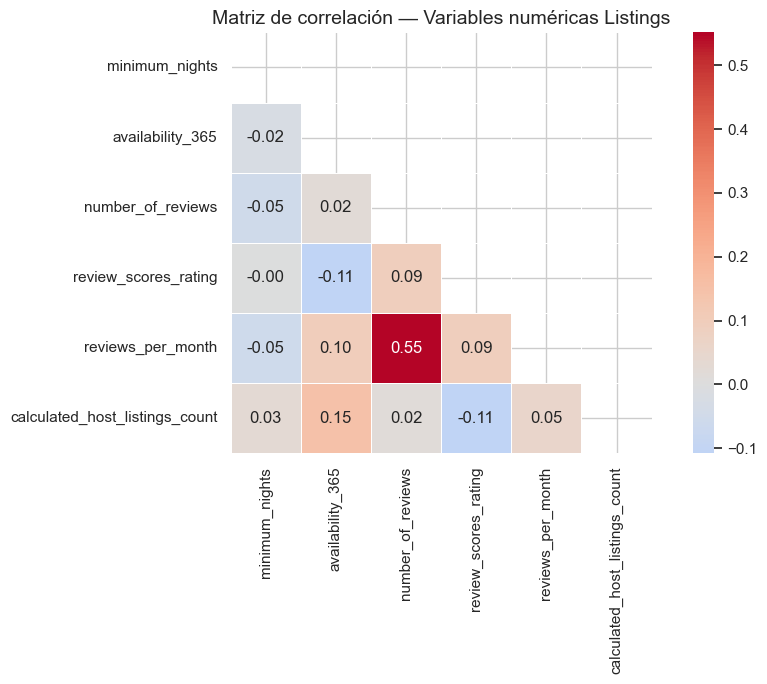

In [24]:
cols_correlacion = ['minimum_nights', 'availability_365', 'number_of_reviews',
                    'review_scores_rating', 'reviews_per_month', 'calculated_host_listings_count']
cols_existentes = [c for c in cols_correlacion if c in df_listings.columns]

if len(cols_existentes) >= 3:
    df_corr = df_listings[cols_existentes].apply(pd.to_numeric, errors='coerce')
    corr_matrix = df_corr.corr()
    
    fig, ax = plt.subplots(figsize=(10, 7))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, ax=ax,
        square=True, linewidths=0.5
    )
    ax.set_title('Matriz de correlación — Variables numéricas Listings')
    plt.tight_layout()
    plt.savefig('../data/grafica_correlacion.png', dpi=150, bbox_inches='tight')
    plt.show()

### Analisis de transformaciones necesarias 

Campo `amenities` de la colección respectiva a los listings

In [40]:
if 'amenities' in df_listings.columns:
    muestra = df_listings['amenities'].dropna().head(10)
    for i, val in enumerate(muestra):
        print(f'Registro {i+1}: {str(val)[:200]}')
    print('\n→ El campo amenities es una lista en formato string. Se debe parsear con ast.literal_eval.')

Registro 1: ['Garden view', 'Resort access', 'Washer', 'Courtyard view', 'Kitchen', 'BBQ grill', 'Free parking on premises', 'Bed linens', 'Wifi', 'Hot water', 'Pocket wifi', 'Indoor fireplace']
Registro 2: ['Piano', 'Patio or balcony', 'Wifi', 'Refrigerator', 'Microwave', 'Stainless steel gas stove', 'Kitchen', 'Free parking on premises', 'Host greets you', 'TV', 'Free street parking', 'Shampoo', 'Washe
Registro 3: ['Self check-in', 'Dining table', 'Elevator', 'Wifi', 'Hot water', 'Microwave', 'Refrigerator', 'Building staff', 'Kitchen', 'Stove', 'Cleaning products', 'Paid parking on premises', 'Extra pillows an
Registro 4: ['Room-darkening shades', 'Dedicated workspace', 'Wifi', 'Hot water', 'Refrigerator', 'Kitchen', 'Stove', 'Sound system', 'Extra pillows and blankets', 'Luggage dropoff allowed', 'Iron', 'Bathtub', 'H
Registro 5: ['Private entrance', 'Laundromat nearby', 'Dining table', 'Outdoor dining area', 'Room-darkening shades', 'Dedicated workspace', 'Private patio or balcony

Campo `price` en la colección listings

In [31]:
if 'price' in df_listings.columns:
    print('Tipo actual:', df_listings['price'].dtype)
    print('Ejemplos:', df_listings['price'].dropna().head(5).tolist())
    print('\n→ Requiere eliminar simbolo de dolar $, comas y convertir a dato de tipo flotante.')

Tipo actual: str
Ejemplos: ['$3,673.00', '$18,000.00', '$591.00', '$3,673.00', '$321.00']

→ Requiere eliminar simbolo de dolar $, comas y convertir a dato de tipo flotante.


Campo `date` en la coleccion calendar

In [32]:
if 'date' in df_calendar.columns:
    print('Tipo actual:', df_calendar['date'].dtype)
    print('Ejemplos:', df_calendar['date'].dropna().head(5).tolist())
    print('\n→ Se convertirá a datetime y se derivarán: año, mes, día, trimestre.')

Tipo actual: datetime64[us]
Ejemplos: [Timestamp('2025-09-28 00:00:00'), Timestamp('2025-09-29 00:00:00'), Timestamp('2025-09-30 00:00:00'), Timestamp('2025-10-01 00:00:00'), Timestamp('2025-10-02 00:00:00')]

→ Se convertirá a datetime y se derivarán: año, mes, día, trimestre.
